In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score


In [2]:
"""
Import the “Human activity.csv” dataset. Remove "subject" from the features as it is a 
number assigned to a person. Separate the features and targets into two separate 
variables. What are the target variable names?
"""
# load and view the data
data = pd.read_csv("Human activity.csv")
data.head(n = 10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING
5,0.277199,-0.010098,-0.105137,-0.997335,-0.990487,-0.995420,-0.997627,-0.990218,-0.995549,-0.942469,...,-0.844619,0.082632,-0.143439,0.275041,-0.368224,-0.849632,0.184823,-0.042126,1,STANDING
6,0.279454,-0.019641,-0.110022,-0.996921,-0.967186,-0.983118,-0.997003,-0.966097,-0.983116,-0.940987,...,-0.564430,-0.212754,-0.230622,0.014637,-0.189512,-0.852150,0.182170,-0.043010,1,STANDING
7,0.277432,-0.030488,-0.125360,-0.996559,-0.966728,-0.981585,-0.996485,-0.966313,-0.982982,-0.940987,...,-0.421715,-0.020888,0.593996,-0.561871,0.467383,-0.851017,0.183779,-0.041976,1,STANDING
8,0.277293,-0.021751,-0.120751,-0.997328,-0.961245,-0.983672,-0.997596,-0.957236,-0.984379,-0.940598,...,-0.572995,0.012954,0.080936,-0.234313,0.117797,-0.847971,0.188982,-0.037364,1,STANDING
9,0.280586,-0.009960,-0.106065,-0.994803,-0.972758,-0.986244,-0.995405,-0.973663,-0.985642,-0.940028,...,0.140452,-0.020590,-0.127730,-0.482871,-0.070670,-0.848294,0.190310,-0.034417,1,STANDING


In [3]:
# drop subject column at the second last column
data = data.drop(data.columns[-2], axis = 1)
data.head(n=10)

# separate the data into features and targets (the last column)
target = data.iloc[:, -1] # activity column
features = data.iloc[:, :-1]

# view unique values in the target column
target.unique()

array(['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

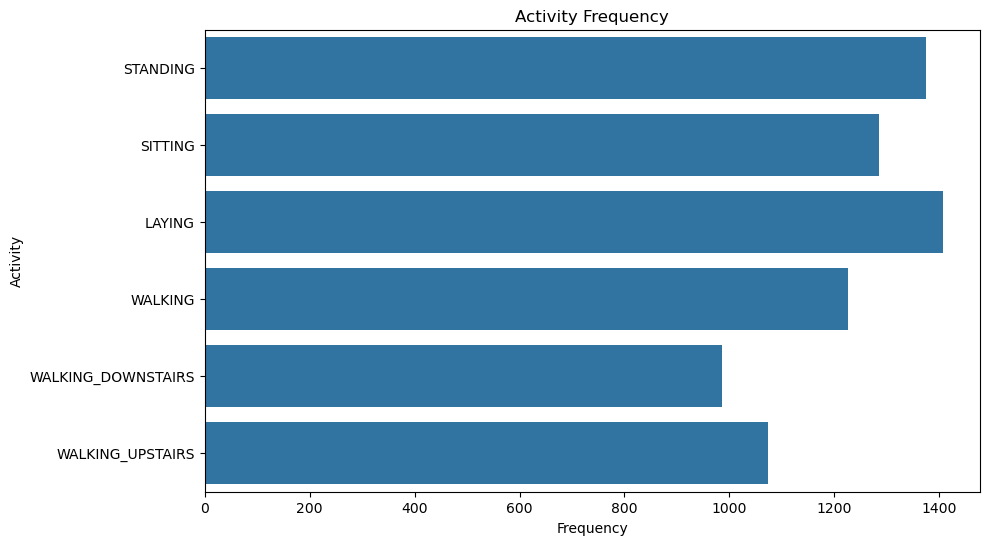

In [4]:
"""
Generate a column chart of the activities. Is the dataset balanced?
"""

# historgram of number of activities and their frequency
plt.figure(figsize=(10, 6))
sns.countplot(target)
plt.title('Activity Frequency')
plt.xlabel('Frequency')
plt.ylabel('Activity')
plt.show()


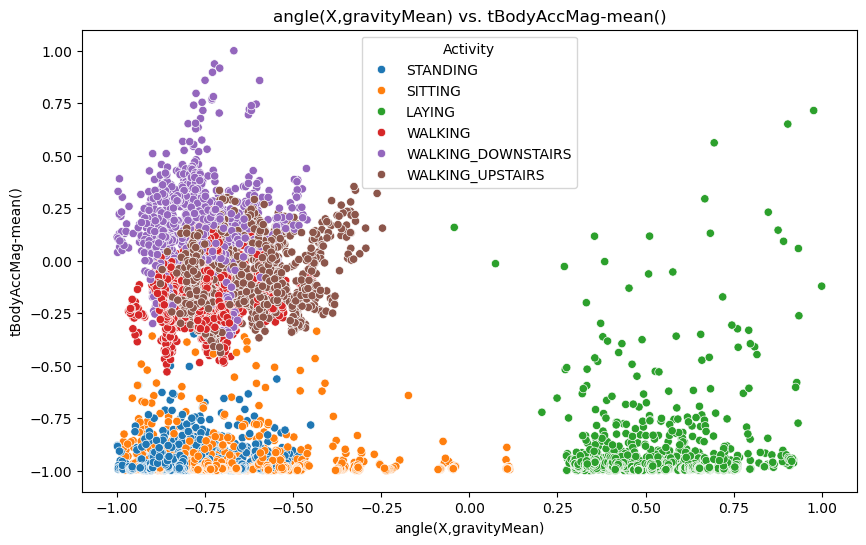

In [5]:
"""
Generate a scatter plot: the angle(X,gravityMean) vs. tBodyAccMag-mean() for the 
Human Activity Recognition dataset where each activity is represented by a different 
marker. 
"""

# create a new dataframe with the required columns
new_data = pd.DataFrame()
new_data['angle(X,gravityMean)'] = features['angle(X,gravityMean)']
new_data['tBodyAccMag-mean()'] = features['tBodyAccMag-mean()']
new_data['Activity'] = target

# scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='angle(X,gravityMean)', y='tBodyAccMag-mean()', hue='Activity', data=new_data)
plt.title('angle(X,gravityMean) vs. tBodyAccMag-mean()')
plt.xlabel('angle(X,gravityMean)')
plt.ylabel('tBodyAccMag-mean()')
plt.show()

new_data = new_data.drop('Activity', axis=1)

- Laying is a distintive activity in this dataset. 
- Walking, walking upstair or downstair is harder to distinct with angular acceleration and gravity mean, but is distinct from other activities meantioned in the graph
- standing and sitting can not be distinguish apart by be told different from all kinds of walking activities and laying

In [6]:
"""
Perform K-means clustering on the dataset not using the labels: 
a. With K=2. Using different markers, show the clusters obtained on a plot. (3 points) 
b. With K=3. Using different markers, show the clusters obtained on a plot. (3 points) 
c. Discuss the results of sections 5.a and 5.b. Using clusters generated, explain how 
selecting a different number of K values affects the clustering. (2.5 points) 
d. Compare sections 5.a and 5.b with the plot generated in section 3. (1.5 points) 
"""

# standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# encoded the target column
label_encoder = LabelEncoder()
target_label = label_encoder.fit_transform(target)

In [7]:
def Kmeans_cluster_n(n, features_scaled, data):
    # KMeans clustering
    kmeans_cluster = KMeans(n_clusters= n, random_state= 42, n_init='auto').fit(features_scaled)
    y_predicted_km = kmeans_cluster.fit_predict(data)
    print(y_predicted_km)
    print(kmeans_cluster.cluster_centers_)

    plt.figure(figsize=(10, 6))
    plt.scatter(data['angle(X,gravityMean)'], data['tBodyAccMag-mean()'], c=y_predicted_km, cmap='viridis')
    plt.scatter(kmeans_cluster.cluster_centers_[:, 0], kmeans_cluster.cluster_centers_[:, 1], s=300, c='red', marker='*') # Changed marker to * for better visibility
    plt.title(f'KMeans Clustering (K={n})')
    plt.xlabel('angle(X,gravityMean)')
    plt.ylabel('tBodyAccMag-mean()')
    plt.show()

[1 1 1 ... 0 0 0]
[[-0.71862997 -0.04665947]
 [-0.29998306 -0.95533349]]


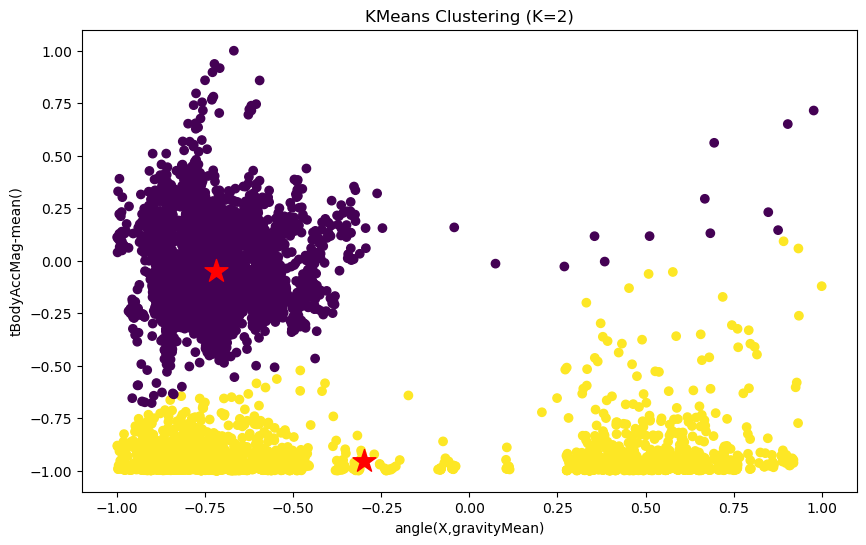

In [8]:
# Cluster number = 2
Kmeans_cluster_n(2, features_scaled, new_data)

[1 1 1 ... 0 0 0]
[[-0.72245738 -0.04471589]
 [-0.74802428 -0.95829744]
 [ 0.49919599 -0.93635537]]


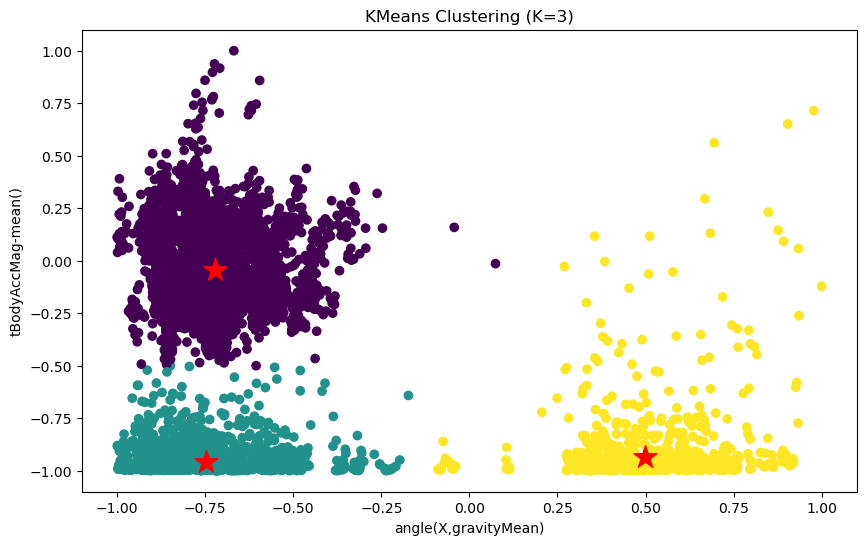

In [9]:
# Cluster number = 3
Kmeans_cluster_n(3, features_scaled, new_data)

### Discuss the results of sections 5.a and 5.b. Using clusters generated, explain how selecting a different number of K values affects the clustering. (2.5 points) 

The number of clustering divided the zone in the dataset differently depending on the number of cluster to divided into. The regions are divided so that the centroids each has a equal area of coverage. As the number of centroids increases, the distance between data points decreases. Too small K leads to distinct data points to be in the same group. Too large K leads to unnecessary fragmentation in classification. K values in this model is seemed to be sensitive to outliers because it tries to minimize the squared error between centroids and data points.

### Compare sections 5.a and 5.b with the plot generated in section 3. (1.5 points) 

In the 2 clusters, the model is able to recognize the different between active (all sorts of walking) and inactive (sitting, standing, laying). In the 3 cluster diagram, the model can tell the different between walking and (sitting, standing) and laying. Comparing to the actual result, the outliers for sitting and laying are not cluster correctly.


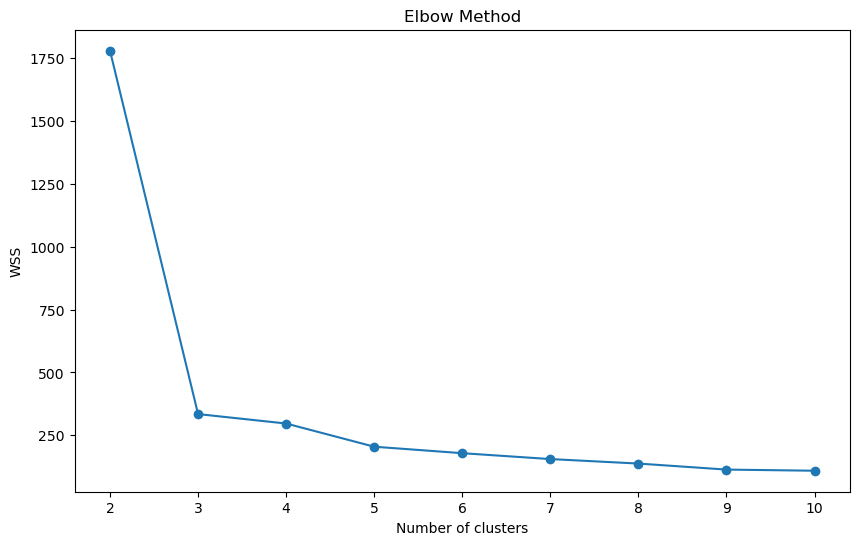

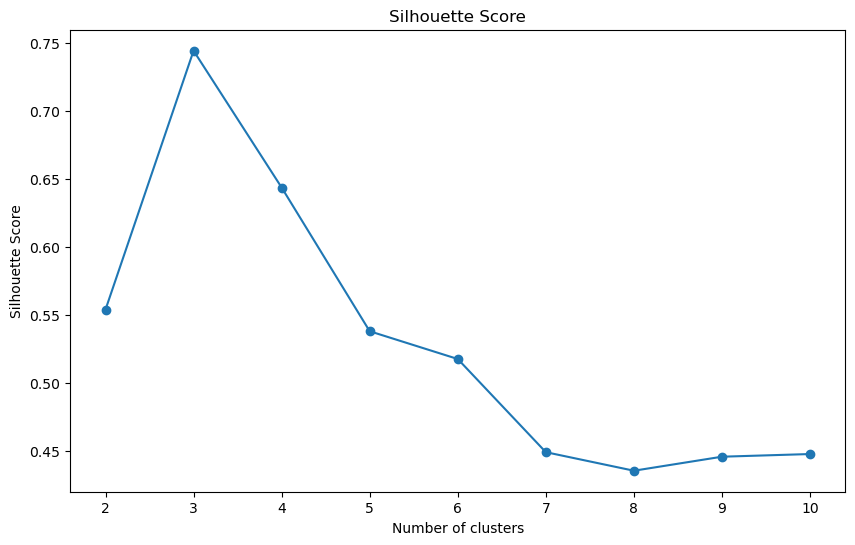

In [10]:
# function returns WSS score for k values from 1 to kmax
sil = []
wss = []

def evaluate_KMean_cluster(points, kmax):
  for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters= k, random_state= 42, n_init='auto').fit(points)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    sil.append(silhouette_score(new_data.values, labels, metric = 'euclidean'))
    pred_clusters = kmeans.predict(points)
    curr_sse = 0

    # calculate square of Euclidean distance of each point from its cluster center and add to current WSS
    for i in range(len(points)):
      curr_center = centroids[pred_clusters[i]]
      curr_sse += (points[i, 0] - curr_center[0]) ** 2 + (points[i, 1] - curr_center[1]) ** 2
      
    wss.append(curr_sse)

evaluate_KMean_cluster(new_data.values, 10)
# plot the WSS values
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WSS')
plt.show()

# plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


In [11]:
"""
Perform K-medoid clustering on the dataset not using the labels: 
a. With K=2. Using different markers, show the clusters obtained on a plot. (3points) 
b. With K=3. Using different markers, show the clusters obtained on a plot. (3 points) 
c. Discuss the results of sections 6.a and 6.b. Using clusters generated, explain how 
selecting a different number of K values affects the clustering. (2.5 points) 
d. Compare sections 6.a and 6.b with the plot generated in section 3. (1.5 points) 
"""

def Kmedoid_cluster_n(n, features_scaled, data):
    # KMeans clustering
    kmedoids_cluster = KMedoids(n_clusters= n, random_state= 42).fit(features_scaled)
    y_predicted_km = kmedoids_cluster.fit_predict(data)
    print(y_predicted_km)
    print(kmedoids_cluster.cluster_centers_)

    plt.figure(figsize=(10, 6))
    plt.scatter(data['angle(X,gravityMean)'], data['tBodyAccMag-mean()'], c=y_predicted_km, cmap='viridis')
    plt.scatter(kmedoids_cluster.cluster_centers_[:, 0], kmedoids_cluster.cluster_centers_[:, 1], s=300, c='red', marker='*') # Changed marker to * for better visibility
    plt.title(f'KMedoids Clustering (K={n})')
    plt.xlabel('angle(X,gravityMean)')
    plt.ylabel('tBodyAccMag-mean()')
    plt.show()

[1 1 1 ... 0 0 0]
[[-0.72693856 -0.06464965]
 [-0.64988656 -0.97293097]]


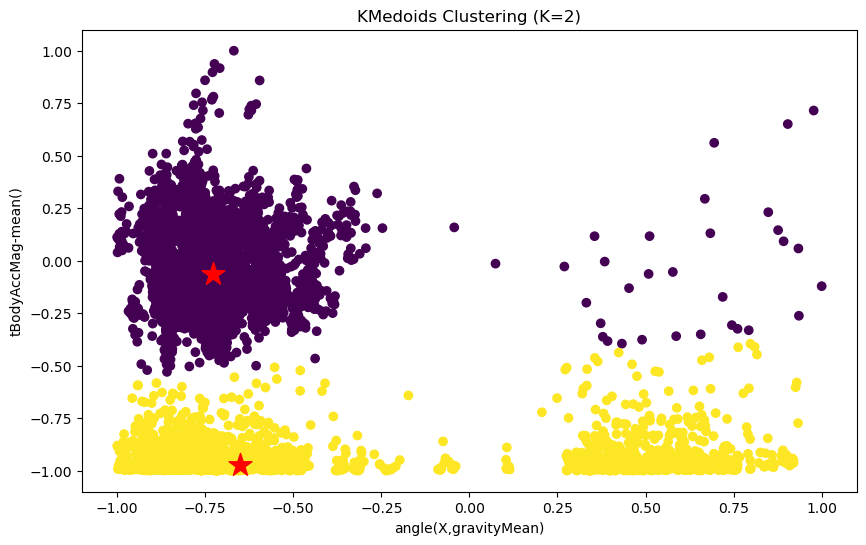

In [12]:
# Cluster number = 2
Kmedoid_cluster_n(2, features_scaled, new_data)

[1 1 1 ... 0 0 2]
[[-0.73957584  0.13018951]
 [-0.64988656 -0.97293097]
 [-0.7360151  -0.1730461 ]]


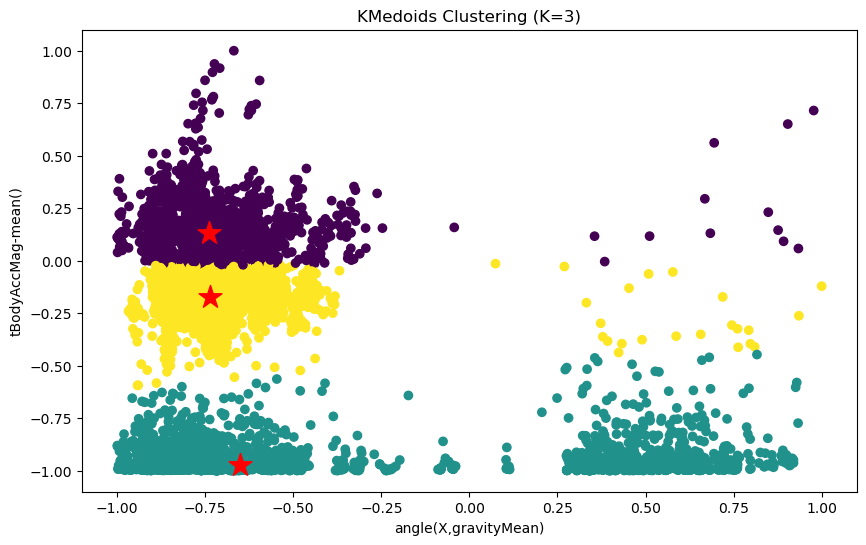

In [13]:
# Cluster number = 3
Kmedoid_cluster_n(3, features_scaled, new_data)

[3 3 3 ... 1 1 2]
[[ 0.50190453 -0.96669875]
 [-0.73957584  0.13018951]
 [-0.7360151  -0.1730461 ]
 [-0.77583114 -0.97300944]]


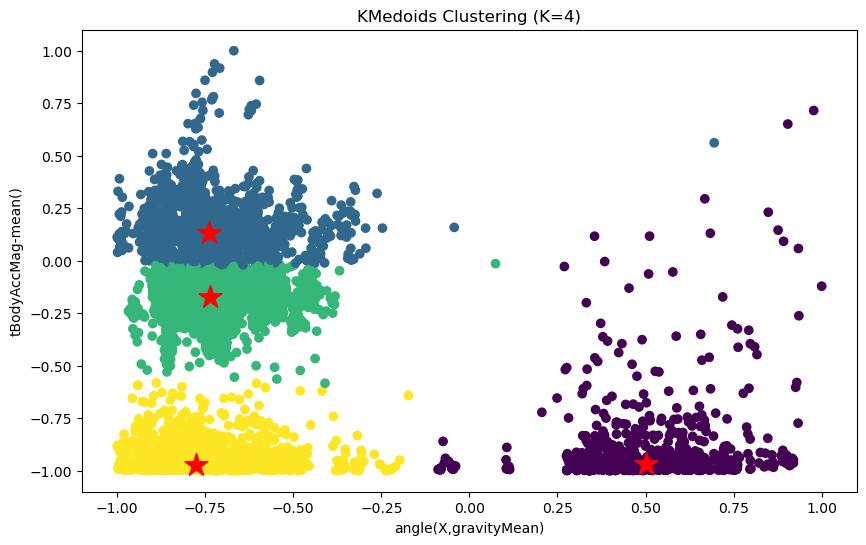

In [14]:
# Cluster number = 4
Kmedoid_cluster_n(4, features_scaled, new_data)

### Discuss the results of sections 6.a and 6.b. Using clusters generated, explain how selecting a different number of K values affects the clustering. (2.5 points) 

The K-Medoids model determines by merging the data points into larger centroids, which is less sensitive to outliers. The effect is similar to K-Means model. Too small k leads to distinct data points treated the same category. Too large k leads to fragmentation

### Compare sections 6.a and 6.b with the plot generated in section 3. (1.5 points) 

The K-Metroid is able to distinguish between stationary (sitting, standing, laying) and moving (all sorts of walking) activities. In the cluster=3, the model does not differentiate between sitting, standing and laying, but vaguely differentiate between different types of walkings (because there are many blending between the 3 different types of walking)


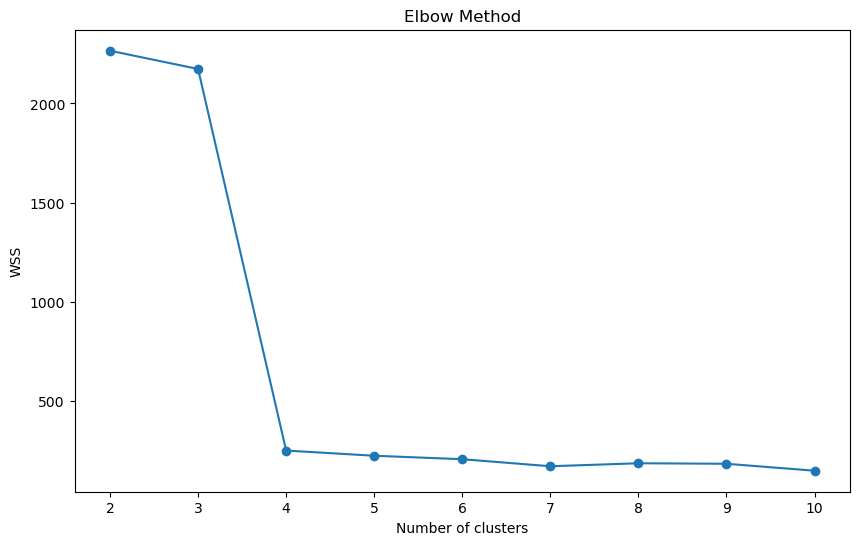

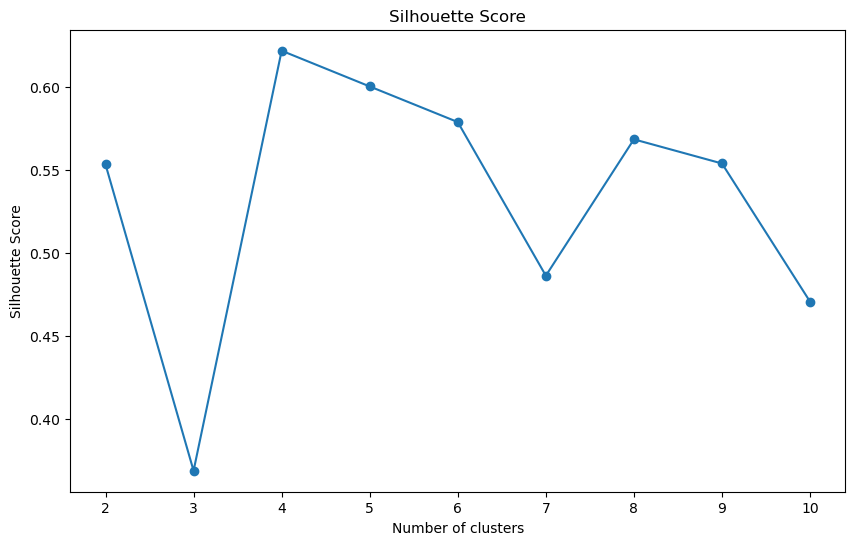

In [15]:
# function returns WSS score for k values from 2 to kmax
sil = []
wss = []

def evaluate_KMedoids_cluster(points, kmax):
  for k in range(2, kmax+1):
    kmeans = KMedoids(n_clusters= k, random_state= 42).fit(points)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    sil.append(silhouette_score(new_data.values, labels, metric = 'euclidean'))
    pred_clusters = kmeans.predict(points)
    curr_sse = 0

    # calculate square of Euclidean distance of each point from its cluster center and add to current WSS
    for i in range(len(points)):
      curr_center = centroids[pred_clusters[i]]
      curr_sse += (points[i, 0] - curr_center[0]) ** 2 + (points[i, 1] - curr_center[1]) ** 2
      
    wss.append(curr_sse)

evaluate_KMedoids_cluster(new_data.values, 10)

# plot the WSS values
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WSS')
plt.show()

# plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()
